# Exemplo 04 - Atendimento: previsão de demanda em um call center

### Palestra Machine Learning e IA: Da máquina que aprende à IA que age

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

**Onde isso aparece no mercado:** Centrais de atendimento, operadoras e bancos preveem quantas chamadas vão chegar em cada dia para montar a escala de atendentes e evitar filas (ou gente ociosa).

**Conceito da palestra:** Regressão sobre série temporal: usamos o passado (tendência e sazonalidade) para prever um número no futuro.

## Objetivo do exemplo

Neste exemplo vamos construir uma pequena análise de séries temporais com um caso de negócio simples:

> **Como prever o volume diário de chamadas de um call center usando dados históricos?**

A ideia não é formar especialistas em forecasting, mas desenvolver intuição sobre:

- o que diferencia uma série temporal de uma base tabular comum;
- tendência, sazonalidade e ruído;
- criação de variáveis temporais;
- divisão treino/teste respeitando o tempo;
- previsão simples com Machine Learning;
- avaliação com métricas de erro.

## 1. Importando bibliotecas

Usaremos bibliotecas comuns do ecossistema Python para dados:

- `pandas` para manipulação de dados;
- `numpy` para geração de dados simulados;
- `matplotlib` para visualização;
- `scikit-learn` para treinar um modelo simples.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

## 2. Criando uma série temporal simulada

Vamos simular um cenário de **volume diário de chamadas em um call center**.

A série terá alguns comportamentos típicos:

- **tendência**: crescimento leve ao longo do tempo;
- **sazonalidade semanal**: alguns dias da semana têm mais chamadas;
- **sazonalidade mensal**: picos próximos ao início do mês;
- **ruído**: variações aleatórias naturais do mundo real.

Em um projeto real, esta etapa seria substituída pela leitura de dados históricos de uma empresa.


In [2]:
# Criando datas diárias para aproximadamente 1 ano e meio
dates = pd.date_range(start="2024-01-01", end="2025-06-30", freq="D")

df = pd.DataFrame({"date": dates})
df["day_index"] = np.arange(len(df))

# Componentes da série temporal
trend = 80 + 0.06 * df["day_index"]  # crescimento leve
weekly_seasonality = df["date"].dt.dayofweek.map({
    0: 25,   # segunda
    1: 15,   # terça
    2: 10,   # quarta
    3: 5,    # quinta
    4: 0,    # sexta
    5: -20,  # sábado
    6: -30   # domingo
})

monthly_effect = np.where(df["date"].dt.day <= 5, 20, 0)  # início do mês
noise = np.random.normal(loc=0, scale=8, size=len(df))

df["calls"] = trend + weekly_seasonality + monthly_effect + noise
df["calls"] = df["calls"].round().astype(int)

df.head()

,date,day_index,calls
0,2024-01-01,0,129
1,2024-01-02,1,114
2,2024-01-03,2,115
3,2024-01-04,3,117
4,2024-01-05,4,98


## 3. Visualizando a série temporal

A primeira pergunta em séries temporais quase sempre é:

> **Como a variável se comporta ao longo do tempo?**

Antes de escolher modelos, precisamos olhar para os dados.


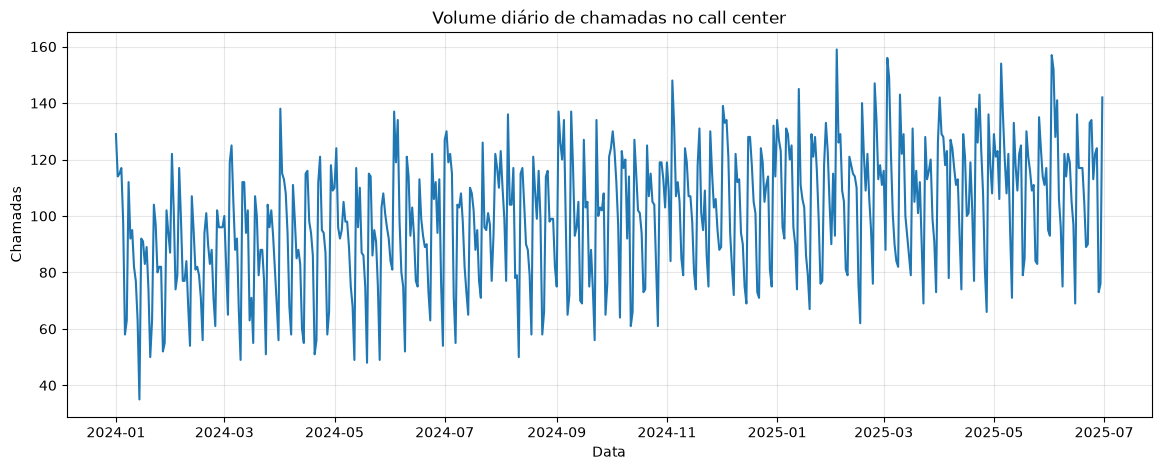

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["calls"])
plt.title("Volume diário de chamadas no call center")
plt.xlabel("Data")
plt.ylabel("Chamadas")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Suavizando a série com média móvel

Séries temporais reais costumam ter muito ruído.

Uma técnica simples para enxergar melhor o comportamento geral é calcular uma **média móvel**.

Aqui usaremos uma janela de 7 dias, que ajuda a suavizar efeitos diários e destacar tendências mais amplas.


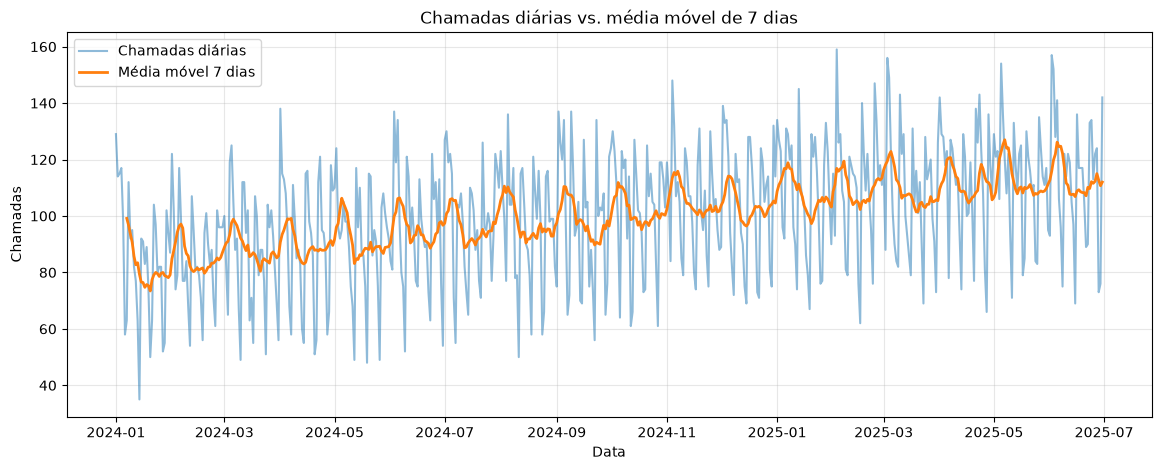

In [4]:
df["moving_avg_7"] = df["calls"].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["calls"], label="Chamadas diárias", alpha=0.5)
plt.plot(df["date"], df["moving_avg_7"], label="Média móvel 7 dias", linewidth=2)
plt.title("Chamadas diárias vs. média móvel de 7 dias")
plt.xlabel("Data")
plt.ylabel("Chamadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Investigando sazonalidade semanal

Nem todo dia da semana se comporta da mesma forma.

Em muitos negócios:

- segunda-feira pode concentrar mais demanda;
- finais de semana podem ter menor volume;
- datas específicas podem gerar picos.

Vamos observar a média de chamadas por dia da semana.


In [5]:
df["day_of_week"] = df["date"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_avg = (
    df.groupby("day_of_week")["calls"]
    .mean()
    .reindex(weekday_order)
)

weekday_avg

day_of_week
Monday       124.860759
Tuesday      115.230769
Wednesday    108.153846
Thursday     105.102564
Friday        98.705128
Saturday      80.153846
Sunday        69.653846
Name: calls, dtype: float64

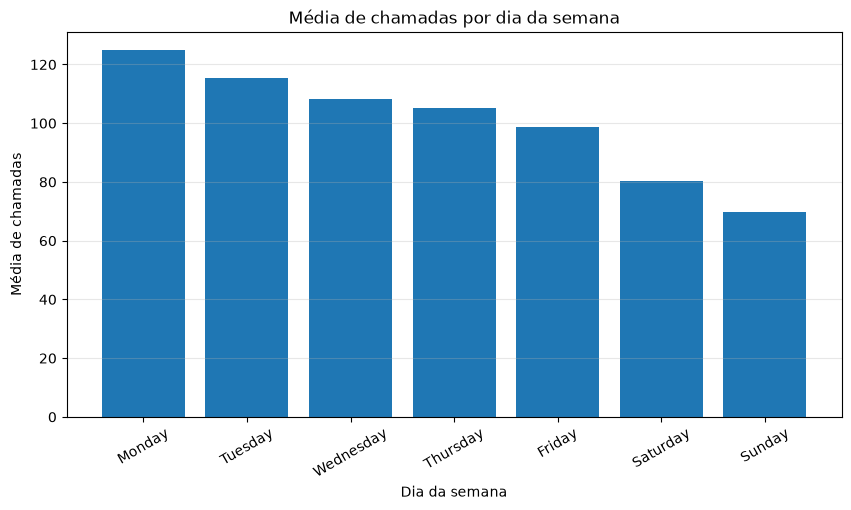

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_avg.index, weekday_avg.values)
plt.title("Média de chamadas por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Média de chamadas")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 6. Transformando tempo em variáveis para Machine Learning

Modelos clássicos de Machine Learning não entendem datas diretamente.

Precisamos transformar o tempo em variáveis úteis, como:

- índice temporal;
- dia da semana;
- mês;
- se é fim de semana;
- chamadas do dia anterior;
- média dos últimos 7 dias.

Essas variáveis são chamadas de **features temporais**.


In [7]:
# Features de calendário
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["day_of_week_num"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)
df["is_month_start"] = (df["day_of_month"] <= 5).astype(int)

# Features de atraso: passado ajudando a prever o futuro
df["calls_lag_1"] = df["calls"].shift(1)
df["calls_lag_7"] = df["calls"].shift(7)
df["rolling_mean_7"] = df["calls"].shift(1).rolling(window=7).mean()

# Removendo linhas iniciais sem histórico suficiente
model_df = df.dropna().copy()

model_df.head()

,date,day_index,calls,moving_avg_7,day_of_week,month,day_of_month,day_of_week_num,is_weekend,is_month_start,calls_lag_1,calls_lag_7,rolling_mean_7
7,2024-01-08,7,112,96.714286,Monday,1,8,0,0,0,63.0,129.0,99.142857
8,2024-01-09,8,92,93.571429,Tuesday,1,9,1,0,0,112.0,114.0,96.714286
9,2024-01-10,9,95,90.714286,Wednesday,1,10,2,0,0,92.0,115.0,93.571429
10,2024-01-11,10,82,85.714286,Thursday,1,11,3,0,0,95.0,117.0,90.714286
11,2024-01-12,11,77,82.714286,Friday,1,12,4,0,0,82.0,98.0,85.714286


## 7. Separando treino e teste do jeito certo

Em problemas tradicionais, muitas vezes usamos divisão aleatória entre treino e teste.

Em séries temporais, isso pode gerar vazamento de informação.

O jeito correto é treinar com o passado e testar no futuro.

Aqui usaremos os últimos 90 dias como teste.


In [8]:
test_days = 90

train = model_df.iloc[:-test_days]
test = model_df.iloc[-test_days:]

features = [
    "day_index",
    "month",
    "day_of_month",
    "day_of_week_num",
    "is_weekend",
    "is_month_start",
    "calls_lag_1",
    "calls_lag_7",
    "rolling_mean_7"
]

target = "calls"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Período de treino:", train["date"].min().date(), "até", train["date"].max().date())
print("Período de teste:", test["date"].min().date(), "até", test["date"].max().date())

Período de treino: 2024-01-08 até 2025-04-01
Período de teste: 2025-04-02 até 2025-06-30


## 8. Modelo baseline: previsão ingênua

Antes de usar Machine Learning, é importante criar um baseline.

Um baseline simples:

> **A previsão de amanhã será igual ao valor de ontem.**

Se o nosso modelo sofisticado não superar isso, ele provavelmente não está agregando valor.


In [9]:
baseline_pred = test["calls_lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline MAE: 19.47
Baseline RMSE: 26.71


## 9. Treinando um modelo simples de regressão

Agora vamos usar uma **Regressão Linear** para prever o volume de chamadas.

Apesar de simples, esse modelo ajuda a mostrar a lógica principal:

- usar variáveis do calendário;
- usar valores passados;
- aprender padrões a partir do histórico;
- prever períodos futuros.


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

test["prediction"] = model.predict(X_test)

model_mae = mean_absolute_error(y_test, test["prediction"])
model_rmse = np.sqrt(mean_squared_error(y_test, test["prediction"]))

print(f"Modelo MAE: {model_mae:.2f}")
print(f"Modelo RMSE: {model_rmse:.2f}")

Modelo MAE: 7.07
Modelo RMSE: 8.81


## 10. Comparando previsões e valores reais

Agora vamos visualizar se o modelo conseguiu acompanhar o comportamento da série no período de teste.


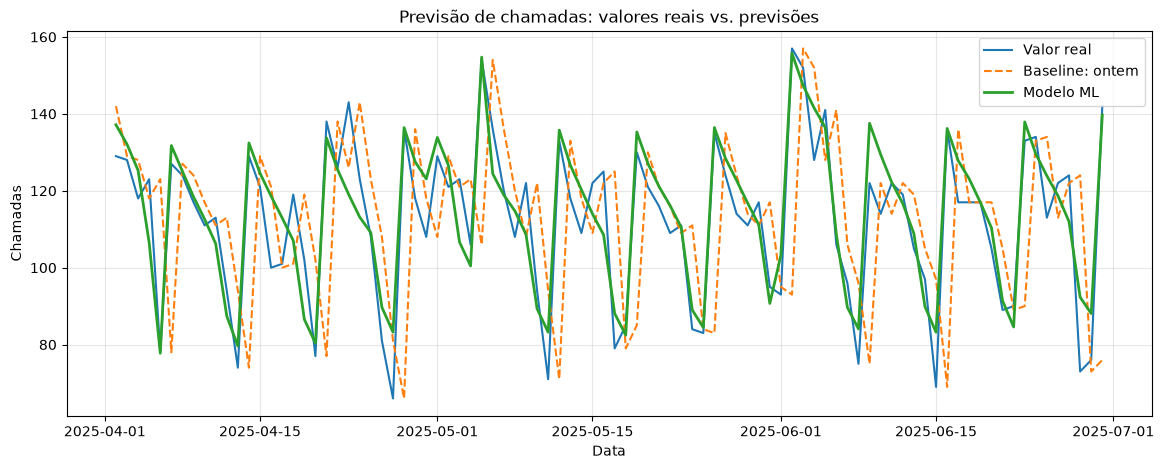

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(test["date"], y_test, label="Valor real")
plt.plot(test["date"], baseline_pred, label="Baseline: ontem", linestyle="--")
plt.plot(test["date"], test["prediction"], label="Modelo ML", linewidth=2)
plt.title("Previsão de chamadas: valores reais vs. previsões")
plt.xlabel("Data")
plt.ylabel("Chamadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Comparando métricas

Duas métricas comuns:

- **MAE**: erro absoluto médio. Fácil de explicar em unidades do problema.
- **RMSE**: penaliza mais erros grandes.

Para uma turma executiva, o MAE costuma ser mais intuitivo:

> “Em média, o modelo erra por aproximadamente X chamadas por dia.”


In [12]:
metrics = pd.DataFrame({
    "Modelo": ["Baseline: valor de ontem", "Regressão Linear com features temporais"],
    "MAE": [baseline_mae, model_mae],
    "RMSE": [baseline_rmse, model_rmse]
})

metrics

,Modelo,MAE,RMSE
0,Baseline: valor de ontem,19.466667,26.709965
1,Regressão Linear com features temporais,7.066992,8.811380


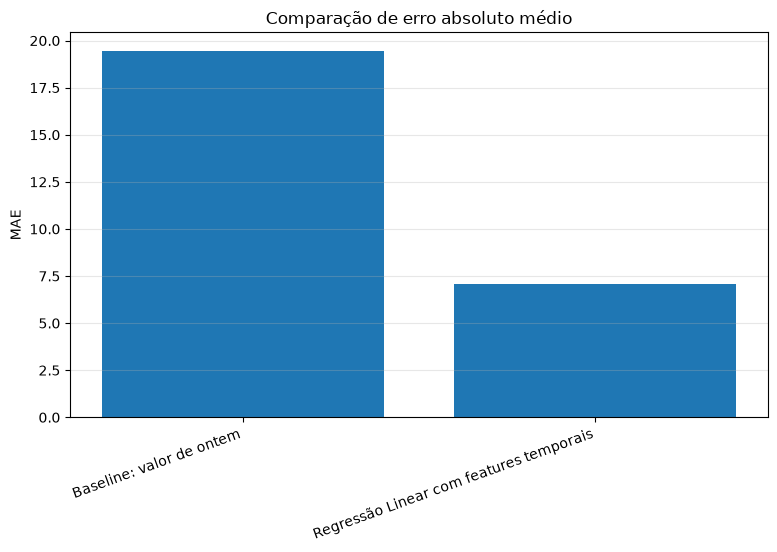

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(metrics["Modelo"], metrics["MAE"])
plt.title("Comparação de erro absoluto médio")
plt.ylabel("MAE")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 12. Interpretando os coeficientes do modelo

Como usamos uma regressão linear, conseguimos olhar para os coeficientes.

Isso ajuda a discutir interpretabilidade:

- quais variáveis aumentam a previsão;
- quais variáveis reduzem a previsão;
- quais variáveis parecem ter mais impacto.


In [14]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
5,is_month_start,22.122905
2,day_of_month,0.149249
8,rolling_mean_7,0.078586
1,month,0.067524
0,day_index,0.056436
7,calls_lag_7,0.050962
6,calls_lag_1,-0.034034
3,day_of_week_num,-6.065893
4,is_weekend,-13.096676


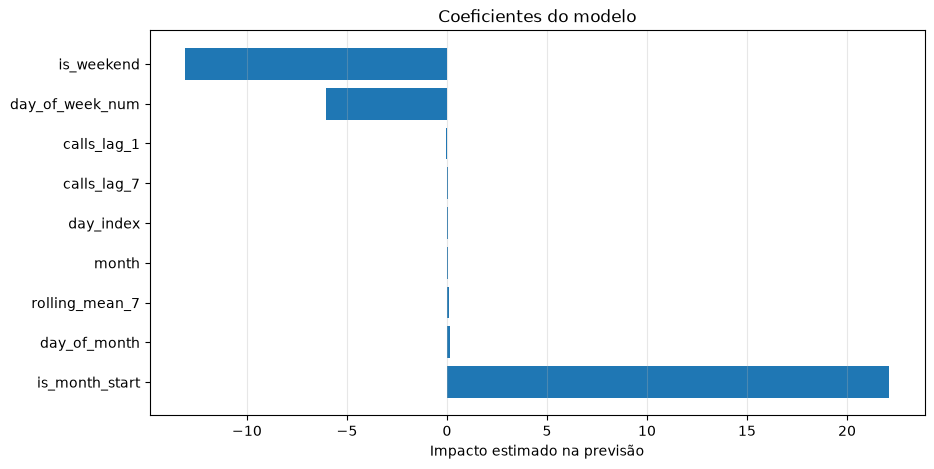

In [15]:
plt.figure(figsize=(10, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.title("Coeficientes do modelo")
plt.xlabel("Impacto estimado na previsão")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## 13. O que este exemplo ensina?

Este exemplo mostra alguns conceitos fundamentais de séries temporais:

1. **Ordem importa**: não podemos embaralhar os dados de qualquer forma.
2. **O passado é uma feature**: valores anteriores ajudam a prever valores futuros.
3. **Sazonalidade importa**: dia da semana e início do mês mudam o comportamento.
4. **Baseline é obrigatório**: um modelo só é útil se melhorar uma referência simples.
5. **Métricas precisam ser interpretáveis**: erro em chamadas/dia é mais fácil de comunicar do que apenas fórmulas abstratas.

## Próximos passos possíveis

Em uma exploração mais avançada, poderíamos testar:

- ARIMA/SARIMA;
- Prophet;
- Random Forest ou XGBoost com features temporais;
- LSTM;
- Transformers para séries temporais;
- detecção de anomalias em séries temporais.


## Fechamento para discussão em sala

> **Se classificação responde “o que é?”, séries temporais tentam responder “o que provavelmente acontecerá”.**

Perguntas para a turma:

1. Em quais áreas da empresa de vocês existem dados organizados por tempo?
2. Que decisões poderiam melhorar com uma previsão simples?
3. Qual seria o custo de errar essa previsão?
4. O que seria mais importante: reduzir o erro médio ou evitar grandes erros em dias críticos?
